In [1]:
import torch
import ChemSurrogate.data_processing as dp
from ChemSurrogate.configs import (
    DatasetConfig,
    AEConfig,
    EMConfig,
    )
import ChemSurrogate.analysis as analysis
from ChemSurrogate.trainer import (
    load_autoencoder_objects,
    load_emulator_objects,
    load_skipcon_emulator_objects,
    )
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import pandas as pd
import os
import gc
import random
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



#species_of_interest = ["H", "H2", "O", "C", "N", "SPlus", "MG", "SIPlus", "CL", "CPlus", "BULK_CO", "BULK_H", "E_minus", "CO", "BULK_CO"]
species_of_interest = ["C"]

In [2]:
# Load the models.
emulator, autoencoder, _, _ = load_skipcon_emulator_objects(is_inference=True)

# Load the datasets
training_t, training_indices = dp.load_tensors_from_hdf5(category="training")
validation_t, validation_indices = dp.load_tensors_from_hdf5(category="validation")

Loading Pretrained Model
Inference Mode Activated (parameters frozen)
Total Parameters: 280088


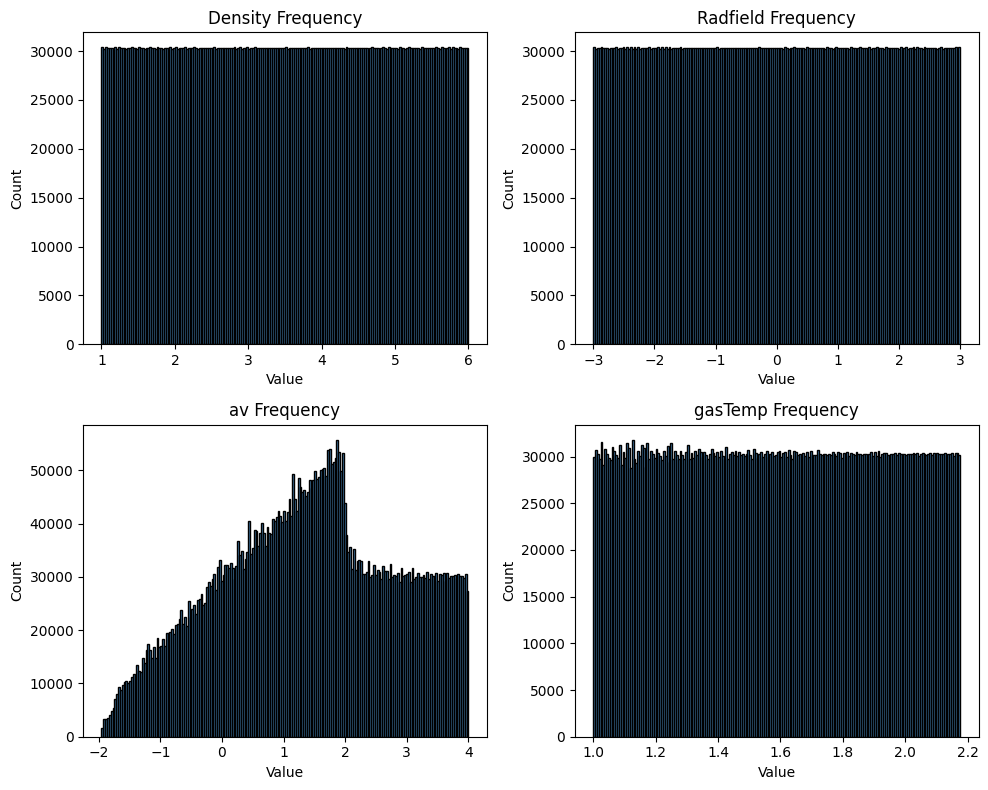

In [3]:
left_index = DatasetConfig.num_metadata
right_index = DatasetConfig.num_metadata + DatasetConfig.num_physical_parameters
physical_parameters = training_t[:, left_index:right_index].numpy()
dp.inverse_physical_parameter_scaling(physical_parameters)

analysis.histogram_physical_parameters(
    sampled_physical_parameters=physical_parameters,
    savefig_path=None,
)

### This section is for obtaining the error plots across species and timesteps.

In [ ]:
validation_Dataset = dp.EmulatorTimestepDataset(validation_t, validation_indices)
validation_dataloader = dp.tensor_to_dataloader(EMConfig, validation_Dataset)

num_timesteps = 100
num_species = DatasetConfig.num_species

total_count = torch.zeros(num_timesteps, dtype=torch.float32).to(device)

total_rel_error = torch.zeros(num_timesteps, num_species, dtype=torch.float32).to(device)
total_mace_error = torch.zeros(num_timesteps, dtype=torch.float32).to(device)
total_conservation_error = torch.zeros(num_timesteps, dtype=torch.float32).to(device)
with torch.no_grad():
    for features, targets in validation_dataloader:
        features = features.to(device)
        targets = targets.to(device)
        emulated_features = dp.emulator_inferencing(emulator, features, scale_components=False)
        decoded_features = dp.decoder_inferencing(autoencoder, emulated_features)
        
        unscaled_targets = dp.inverse_abundances_scaling(targets)
        
        conservation_error = analysis.calculate_conservation_error(unscaled_targets, decoded_features)
        relative_error = analysis.calculate_relative_error(decoded_features, unscaled_targets)
        mace_error = analysis.calculate_mace_error(decoded_features, unscaled_targets)
        
        timesteps = (features[:, 0] * num_timesteps).round().long() - 1
        timesteps_species = timesteps.unsqueeze(1).expand(-1, num_species)
        
        sample_count = torch.ones(features.size(0), dtype=torch.float32, device=device)
        total_count.scatter_add_(0, timesteps, sample_count)
                
        total_rel_error.scatter_add_(0, timesteps_species, relative_error)
        total_mace_error.scatter_add_(0, timesteps, mace_error)
        total_conservation_error.scatter_add_(0, timesteps, conservation_error)

mean_rel_error_timestep_species = torch.zeros_like(total_rel_error.cpu())
mean_rel_error_timestep_species = (
    total_rel_error.cpu() / total_count.cpu().unsqueeze(1)
)

mean_rel_error_across_species = mean_rel_error_timestep_species.mean(dim=1)
std_rel_error_timestep = mean_rel_error_timestep_species.std(dim=1)
mean_mace_error_timestep = total_mace_error.cpu() / total_count.cpu()
mean_conservation_error_timestep = total_conservation_error.cpu() / total_count.cpu()

Data_matrix Memory usage: 2712.402 MB
Index_pairs Memory usage: 1155.85 MB

Dataset Size: 2020000 | Index Pairs: 101000000



In [ ]:
topk = 100

errors = mean_rel_error_timestep_species.mean(axis=0).numpy().flatten()

species_errors = pd.DataFrame({'Species': DatasetConfig.species, 'Error': errors})

species_errors = species_errors.sort_values(by='Error', ascending=False).head(topk)

plt.figure(figsize=(30, 4))
plt.bar(species_errors['Species'], species_errors['Error']*100)
plt.xlabel('Chemical Species')
plt.ylabel('Mean Percentage Error')
plt.xticks(rotation=90)
plt.title(f'Top {topk} Chemical Species with Highest Error Rates')
plt.show()

In [8]:
def plot_error_vs_time(
    errors: torch.Tensor,
    label: str = 'Mean MRE across species',
    save_path: str = "plots/errors/unnamed.png"
    ):
    """
    Helper function for plotting errors across time.
    """
    save_path = os.path.join(DatasetConfig.working_path, save_path)
    
    errors = errors.cpu().numpy()
    timesteps = np.arange(DatasetConfig.num_timesteps_per_model)

    plt.figure(figsize=(5, 4))
    plt.scatter(timesteps + 1, errors, label=f'{label}\nMin: {errors.min():.1f}%\nMax: {errors.max():.1f}%\nMean: {errors.mean():.1f}%', color='b', zorder=2)
    plt.plot(timesteps + 1, errors, color='b', linewidth=1, alpha=0.7, zorder=1)

    plt.xlabel('Timestep Δt (x1kyr)')
    plt.ylabel(f'{label}')
    plt.title(f'{label} vs. Timestep')
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

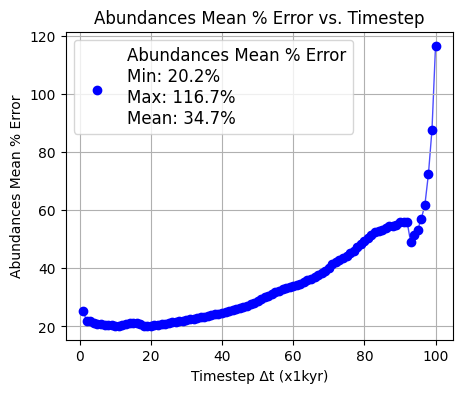

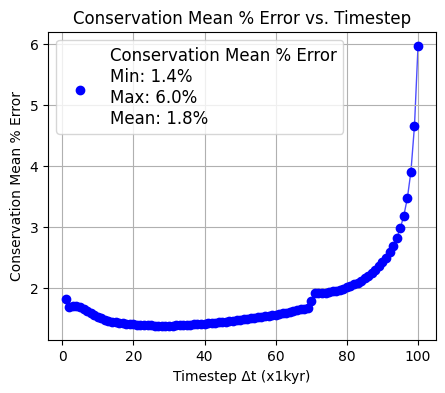

In [9]:
plot_error_vs_time(
    mean_rel_error_across_species*100,
    label = "Abundances Mean % Error",
    save_path = "plots/errors/mean_relative_errors.png"
    )
# analysis.plot_error_vs_time(
#     std_rel_error_timestep,
#     label = "STD of Mean Relative Error Across Species",
#     save_path = "plots/errors/std_relative_errors.png"
#     )
plot_error_vs_time(
    mean_conservation_error_timestep*100,
    label = "Conservation Mean % Error",
    save_path = "plots/errors/conservation_errors.png"
    )


# Abundances vs. Physical Parameters

In [9]:
num_samples = 500000
timestep = 90
initial_conditions = analysis.sample_initial_conditions(num_samples)
initial_conditions_with_time = analysis.add_timesteps_to_conditions(initial_conditions, timestep)

import time
gc.collect()
start_time = time.time()
with torch.no_grad():
    inputs = torch.from_numpy(initial_conditions_with_time).float()
    latent_components = dp.encoder_inferencing(autoencoder, inputs[:, -DatasetConfig.num_species:])
    encoded_features = torch.cat((inputs[:, :1+DatasetConfig.num_physical_parameters], latent_components.cpu()), dim=1)
    encoded_features = dp.emulator_inferencing(emulator, encoded_features)
    decoded_features = dp.decoder_inferencing(autoencoder, encoded_features).cpu().numpy()

inference_df = analysis.reconstruct_results(initial_conditions_with_time, decoded_features)
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.5f} seconds")

#8.84265

Elapsed time: 2.22021 seconds


In [7]:
timestep = 90
num_samples = 100000

filtered_t = training_t[training_t[:, 2] == timestep*1000][:, DatasetConfig.num_metadata:-AEConfig.latent_dim].numpy()
dp.inverse_physical_parameter_scaling(filtered_t[:, :DatasetConfig.num_physical_parameters])
dp.inverse_abundances_scaling_np(filtered_t[:, DatasetConfig.num_physical_parameters:])
training_df = pd.DataFrame(filtered_t, columns=DatasetConfig.physical_parameters + DatasetConfig.species)

initial_conditions = analysis.sample_initial_conditions(num_samples)
initial_conditions_with_time = analysis.add_timesteps_to_conditions(initial_conditions, timestep)


with torch.no_grad():
    inputs = torch.from_numpy(initial_conditions_with_time).float()
    latent_components = dp.encoder_inferencing(autoencoder, inputs[:, -DatasetConfig.num_species:])
    encoded_features = torch.cat((inputs[:, :1+DatasetConfig.num_physical_parameters], latent_components.cpu()), dim=1)
    encoded_features = dp.emulator_inferencing(emulator, encoded_features)
    decoded_features = dp.decoder_inferencing(autoencoder, encoded_features).cpu().numpy()

inference_df = analysis.reconstruct_results(initial_conditions_with_time, decoded_features)

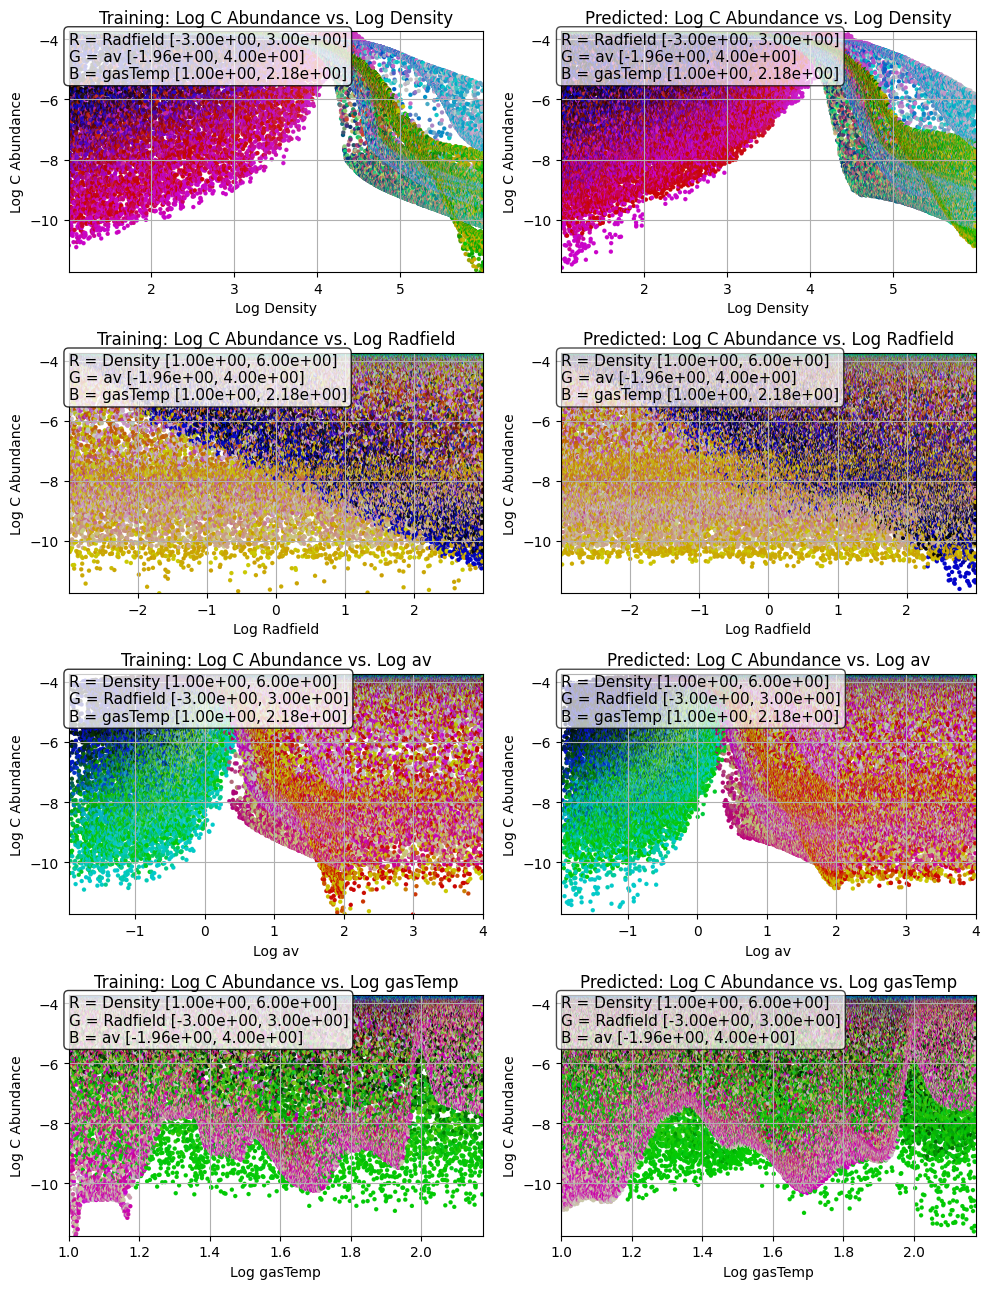

In [8]:
def scatter_abundances_vs_physical_parameters(
    training_df: pd.DataFrame,
    inference_df: pd.DataFrame,
    species_of_interest: list,
    output_folder: str = "plots/compare_scatter_abundances",
    ):
    """
    Generates comparative scatter plots of training vs. predicted abundances
    for each species vs. each physical parameter.
    """
    
    combined_df = pd.concat([training_df, inference_df], ignore_index=True)
    global_mins = np.log10(combined_df[DatasetConfig.physical_parameters].min())
    global_maxs = np.log10(combined_df[DatasetConfig.physical_parameters].max())
    
    for species in species_of_interest:
        fig, axes = plt.subplots(4, 2, figsize=(10, 13))
        
        for i, varying_param in enumerate(DatasetConfig.physical_parameters):
            df_subset = training_df.sort_values(by=varying_param, ascending=True)
            other_params = [p for p in DatasetConfig.physical_parameters if p != varying_param]
            df_color = np.log10(df_subset[other_params].astype(float))
            colors = (df_color - global_mins[other_params]) / (
                global_maxs[other_params] - global_mins[other_params]
            )
            colors = (colors - colors.min()) / (colors.max() - colors.min())
            colors = 1 / (1 + np.exp(-10 * (colors - 0.5)))
            colors *= 0.8
            colors = colors.to_numpy()

            ax_train = axes[i, 0]
            ax_train.scatter(
                np.log10(df_subset[varying_param]),
                np.log10(df_subset[species]),
                c=colors,
                marker='.',
                linewidth=0.1
            )
            ax_train.set_xlabel(f"Log {varying_param}")
            ax_train.set_ylabel(f"Log {species} Abundance")
            ax_train.set_title(f"Training: Log {species} Abundance vs. Log {varying_param}")
            ax_train.grid(True)

            channel_info = (
                f"R = {other_params[0]} "
                f"[{global_mins[other_params[0]]:.2e}, {global_maxs[other_params[0]]:.2e}]\n"
                f"G = {other_params[1]} "
                f"[{global_mins[other_params[1]]:.2e}, {global_maxs[other_params[1]]:.2e}]\n"
                f"B = {other_params[2]} "
                f"[{global_mins[other_params[2]]:.2e}, {global_maxs[other_params[2]]:.2e}]"
            )
            ax_train.text(
                0., 1,
                channel_info,
                transform=ax_train.transAxes,
                va='top',
                ha='left',
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
            )

            df_subset = inference_df.sort_values(by=varying_param, ascending=True)
            df_color = np.log10(df_subset[other_params].astype(float))
            colors = (df_color - global_mins[other_params]) / (
                global_maxs[other_params] - global_mins[other_params]
            )
            colors = (colors - colors.min()) / (colors.max() - colors.min())
            colors = 1 / (1 + np.exp(-10 * (colors - 0.5)))
            colors *= 0.8
            colors = colors.to_numpy()

            ax_pred = axes[i, 1]
            ax_pred.scatter(
                np.log10(df_subset[varying_param]),
                np.log10(df_subset[species]),
                c=colors,
                marker='.',
                linewidth=0.1
            )
            ax_pred.set_xlabel(f"Log {varying_param}")
            ax_pred.set_ylabel(f"Log {species} Abundance")
            ax_pred.set_title(f"Predicted: Log {species} Abundance vs. Log {varying_param}")
            ax_pred.grid(True)

            ax_pred.text(
                0., 1,
                channel_info,
                transform=ax_pred.transAxes,
                va='top',
                ha='left',
                fontsize=11,
                bbox=dict(facecolor='white', alpha=0.7, boxstyle='round')
            )
            
            y_min = min(np.log10(training_df[species].min()), np.log10(inference_df[species].min()))
            y_max = max(np.log10(training_df[species].max()), np.log10(inference_df[species].max()))
            x_min = min(np.log10(training_df[varying_param].min()), np.log10(inference_df[varying_param].min()))
            x_max = max(np.log10(training_df[varying_param].max()), np.log10(inference_df[varying_param].max()))
            
            ax_train.set_xlim(x_min, x_max)
            ax_train.set_ylim(y_min, y_max)
            ax_pred.set_xlim(x_min, x_max)
            ax_pred.set_ylim(y_min, y_max)

        plt.tight_layout()
        folder_path = os.path.join(DatasetConfig.working_path, output_folder)
        if not os.path.exists(folder_path):
            os.makedirs(folder_path)
        savefig_path = os.path.join(folder_path, f"{species}.png")
        plt.savefig(savefig_path, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig)

output_folder = "plots/abundances_vs_physical_parameters"
scatter_abundances_vs_physical_parameters(
    training_df = training_df,
    inference_df = inference_df,
    species_of_interest = species_of_interest,
    output_folder = output_folder
    )

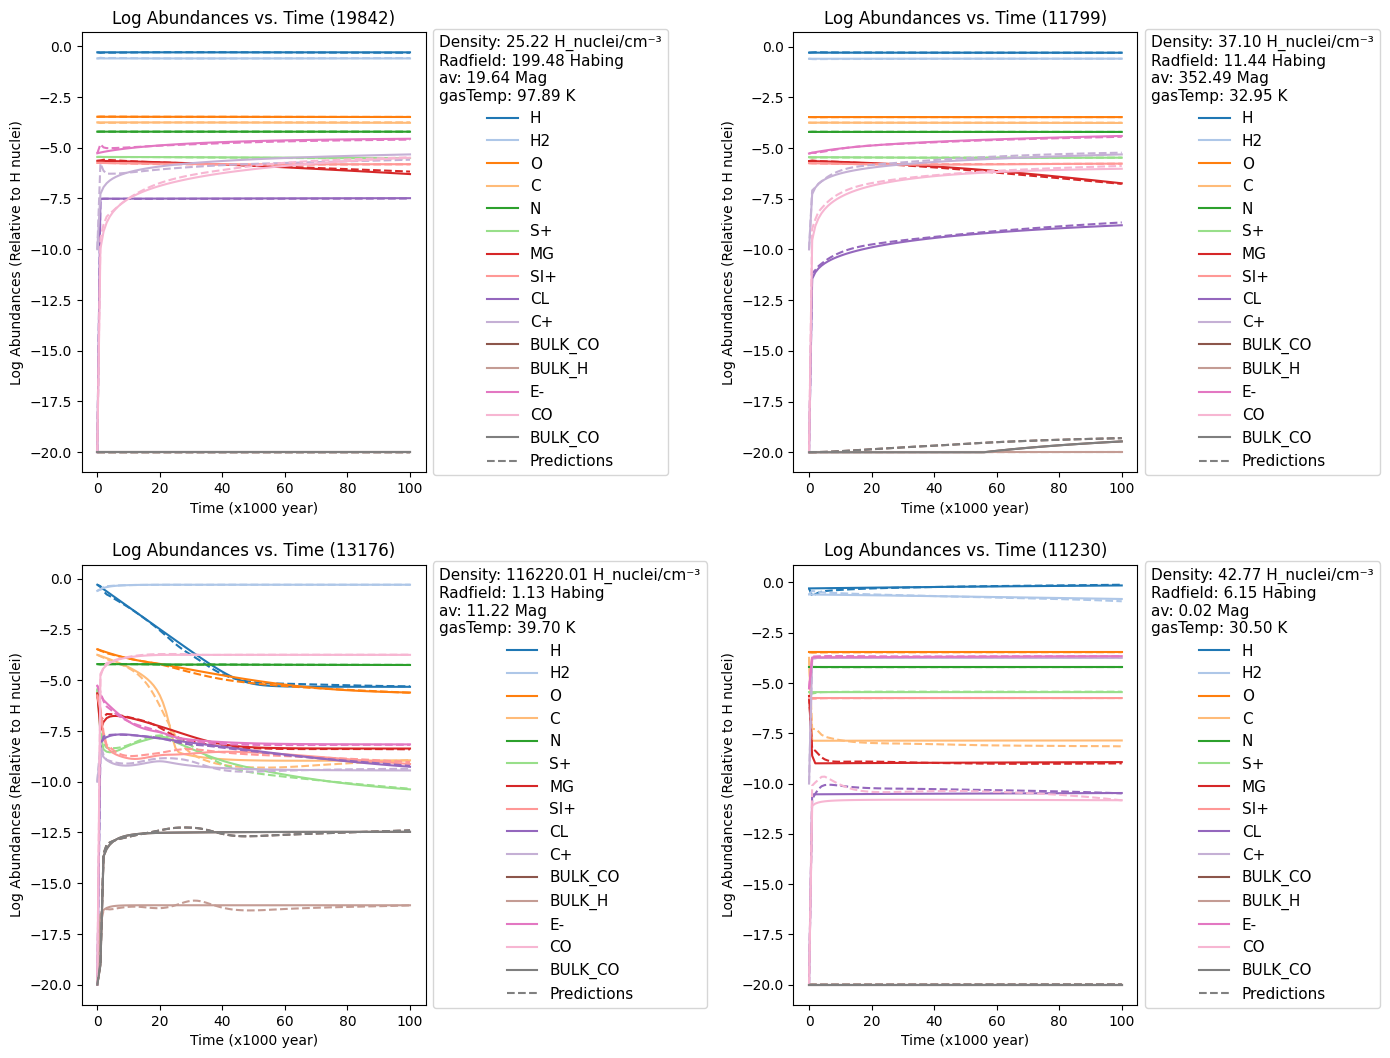

In [ ]:
def clean_label(label):
    return label.replace("Plus", "+").replace("_minus", "-")

num_plots = 2 * 2
sampled_model_indices = random.sample(range(20000), num_plots)

fig, axes = plt.subplots(int(num_plots // 2), 2, figsize=(14, num_plots * 2.7))
axes = axes.flatten()

for i, model_idx_num in enumerate(sampled_model_indices):
    model_idx = validation_t[:, 1].unique()[model_idx_num]
    model_t = validation_t[validation_t[:, 1] == model_idx][:, 2:-AEConfig.latent_dim]
    model_np = np.array(model_t)
    
    dp.inverse_abundances_scaling_np(model_np[:, 1 + DatasetConfig.num_physical_parameters:])

    initial_conditions = model_t[0, 1:].unsqueeze(0)
    initial_conditions_with_time = analysis.add_multiple_timesteps_to_conditions(
        initial_conditions, num_timesteps=model_t.shape[0] - 1).float()

    with torch.no_grad():
        encoded_features = dp.encoder_inferencing(autoencoder, initial_conditions_with_time[:, 1 + DatasetConfig.num_physical_parameters:])
        encoded_features = torch.cat((
            initial_conditions_with_time[:, :1 + DatasetConfig.num_physical_parameters], 
            encoded_features.cpu()), dim=1)
        encoded_features = dp.emulator_inferencing(emulator, encoded_features)
        decoded_features = dp.decoder_inferencing(autoencoder, encoded_features).cpu().numpy()

    initial_abundances = model_np[0, 1 + DatasetConfig.num_physical_parameters:][np.newaxis, :]
    decoded_features = np.vstack([initial_abundances, decoded_features])
    
    columns = DatasetConfig.physical_parameters + DatasetConfig.species
    actual_df = pd.DataFrame(model_np[:, 1:], columns=columns)
    results_df = analysis.reconstruct_results(model_np, decoded_features)

    # Rename columns just for display purposes
    display_column_map = {col: clean_label(col) for col in actual_df.columns}
    actual_df.rename(columns=display_column_map, inplace=True)
    results_df.rename(columns=display_column_map, inplace=True)

    plt.sca(axes[i])
    
    physical_parameters = actual_df.loc[:, [clean_label(p) for p in DatasetConfig.physical_parameters]]
    phys_params = physical_parameters.iloc[0]
    params_text = "\n".join([
        f"{param}: {phys_params[param]:.2f}" 
        for param in physical_parameters.columns
    ])
    
    timesteps = np.arange(0, min(len(actual_df), len(results_df)))
    colors = plt.colormaps.get_cmap('tab20')
    
    for idx, species in enumerate(species_of_interest):
        species_display = clean_label(species)
        plt.plot(
            timesteps, 
            np.log10(actual_df[species_display])[:len(timesteps)], 
            label=species_display, 
            color=colors(idx), 
            linestyle="-"
        )
        plt.plot(
            timesteps, 
            np.log10(results_df[species_display])[:len(timesteps)], 
            color=colors(idx), 
            linestyle="--"
        )

    plt.plot([], [], linestyle="--", color="gray", label="Predictions")

    plt.xlabel("Time (x1000 year)")
    plt.ylabel("Log Abundances (Relative to H nuclei)")
    plt.title(f"Log Abundances vs. Time ({int(model_idx)})")
    plt.legend(
        loc='center left', 
        bbox_to_anchor=(1, 0.5), 
        title=params_text, 
        fontsize=11,
        title_fontsize=11
    )

    output_path = f"plots/abundances_vs_time/model_{int(model_idx)}.png"
    
    # Single figure output
    single_fig = plt.figure(figsize=(7, 6))
    for idx, species in enumerate(species_of_interest):
        species_display = clean_label(species)
        plt.plot(
            timesteps, 
            np.log10(actual_df[species_display])[:len(timesteps)], 
            label=species_display, 
            color=colors(idx), 
            linestyle="-"
        )
        plt.plot(
            timesteps, 
            np.log10(results_df[species_display])[:len(timesteps)], 
            color=colors(idx), 
            linestyle="--"
        )

    plt.plot([], [], linestyle="--", color="gray", label="Predictions")

    plt.xlabel("Time (x1000 year)")
    plt.ylabel("Log Abundances (Relative to H nuclei)")
    plt.title(f"Log Abundances vs. Time")
    plt.legend(
        loc='center left', 
        bbox_to_anchor=(1, 0.5), 
        title=params_text, 
        fontsize=11,
        title_fontsize=11
    )
    plt.tight_layout()

    output_path = os.path.join(DatasetConfig.working_path, output_path)
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(single_fig)

plt.tight_layout()
plt.show()
plt.close(fig)


In [ ]:
num_plots = 10 * 2
sampled_model_indices = random.sample(range(20000), num_plots)

fig, axes = plt.subplots(int(num_plots//2), 2, figsize=(15, num_plots*2))
axes = axes.flatten()

for plot_idx, model_idx_num in enumerate(sampled_model_indices):
    model_idx = validation_t[:, 1].unique()[model_idx_num]
    
    model_np = validation_t[validation_t[:, 1] == model_idx][:, 2:-AEConfig.latent_dim].numpy()
    
    abundances = model_np[:, 5:]
    abundances_t = torch.from_numpy(abundances)
    
    with torch.no_grad():
        encoded_features = dp.encoder_inferencing(autoencoder, abundances_t)
    
    time_indices = (model_np[:, 0] / 1000)
    encoded_features_np = encoded_features.cpu().numpy()
    
    for i in range(encoded_features_np.shape[1]):
        axes[plot_idx].plot(time_indices, encoded_features_np[:, i], label=f'Feature {i+1}')
    
    axes[plot_idx].set_xlabel("Time Index")
    axes[plot_idx].set_ylabel("Encoded Feature Value")
    axes[plot_idx].set_title(f"Model {model_idx_num}")
    axes[plot_idx].grid(True)
    
    if plot_idx == 0:
        axes[plot_idx].legend(loc="lower right")
    else:
        axes[plot_idx].legend(loc="lower right", fontsize='small')

plt.tight_layout()
plt.show()